In [112]:
!pip install yfinance
!pip install pandas
!pip install numpy
!pip install matplotlib
!pip install scipy
!pip install seaborn

In [113]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.optimize as sco
from scipy.optimize import minimize

# 1. Define Tickers and Date Range
tickers = ['AAPL', 'BKR', 'CSX', 'NVDA', 'TSLA']
start_date = '2023-01-09'
end_date = '2026-01-08'

# 2. Fetch Data (FIXED SECTION)
print(f"Downloading data for: {tickers}")

# auto_adjust=True makes 'Close' the adjusted price, avoiding the 'Adj Close' error
raw_data = yf.download(tickers, start=start_date, end=end_date, auto_adjust=True)

# Check if data is empty (Common issue in Colab due to Yahoo blocking IPs)
if raw_data.empty:
    print("ERROR: Data is empty. Yahoo Finance might be blocking this Colab IP.")
    print("Try running the code again in a few minutes or proceed with valid data.")
else:
    # Select just the 'Close' column (which is adjusted)
    data = raw_data['Close']

    # Drop rows with missing values
    data = data.dropna()

    print("Data download complete.")
    print(data.head())

    # --- Proceed with the rest of your calculation ---
    # Only run the next steps if data exists
    if not data.empty:
        # 3. Daily Log Returns
        log_returns = np.log(data / data.shift(1)).dropna()

        # 4. Annualized Statistics
        risk_free_rate = 0.02
        TRADING_DAYS = 252
        mean_returns = log_returns.mean() * TRADING_DAYS
        cov_matrix = log_returns.cov() * TRADING_DAYS
        asset_volatility = log_returns.std() * np.sqrt(TRADING_DAYS)

        print("\n--- Annualized Covariance Matrix ---")
        print(cov_matrix)

        # ... (You can paste the rest of the calculation/plotting code here)

[*********************100%***********************]  5 of 5 completed

Data download complete.
Ticker            AAPL        BKR        CSX       NVDA        TSLA
Date                                                               
2023-01-09  128.215714  28.451239  30.766359  15.612373  119.769997
2023-01-10  128.787079  28.758663  31.015245  15.893089  118.849998
2023-01-11  131.506088  28.721403  31.063110  15.984998  123.220001
2023-01-12  131.427216  29.345579  31.101398  16.494486  123.559998
2023-01-13  132.757172  29.466686  31.034388  16.882099  122.400002

--- Annualized Covariance Matrix ---
Ticker      AAPL       BKR       CSX      NVDA      TSLA
Ticker                                                  
AAPL    0.064487  0.019967  0.017773  0.046183  0.065958
BKR     0.019967  0.091980  0.022485  0.031783  0.046837
CSX     0.017773  0.022485  0.047505  0.016765  0.024644
NVDA    0.046183  0.031783  0.016765  0.244318  0.110739
TSLA    0.065958  0.046837  0.024644  0.110739  0.353390


In [114]:
def get_portfolio_metrics(weights, mean_returns, cov_matrix, rf_rate):
    weights = np.array(weights)

    # Expected Portfolio Return
    port_return = np.sum(mean_returns * weights)

    # Expected Portfolio Volatility (Standard Deviation)
    # Formula: sqrt(w.T * Cov * w)
    port_volatility = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))

    # Sharpe Ratio
    sharpe_ratio = (port_return - rf_rate) / port_volatility

    return port_return, port_volatility, sharpe_ratio

# Helper functions for scipy.optimize
def neg_sharpe_ratio(weights, mean_returns, cov_matrix, rf_rate):
    # We want to MAXIMIZE Sharpe, but scipy MINIMIZES, so we return negative Sharpe
    return -get_portfolio_metrics(weights, mean_returns, cov_matrix, rf_rate)[2]

def volatility_func(weights, mean_returns, cov_matrix, rf_rate):
    # We want to MINIMIZE volatility
    return get_portfolio_metrics(weights, mean_returns, cov_matrix, rf_rate)[1]

In [115]:
num_assets = len(tickers)
args = (mean_returns, cov_matrix, risk_free_rate)

# Constraints: Sum of weights must equal 1
constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})

# Bounds: Weights must be between 0 and 1 (No short selling)
bounds = tuple((0, 1) for _ in range(num_assets))

# Initial Guess (Equal weights)
init_guess = num_assets * [1. / num_assets,]

# --- A. Max Sharpe Ratio Portfolio ---
max_sharpe_result = minimize(neg_sharpe_ratio, init_guess, args=args,
                             method='SLSQP', bounds=bounds, constraints=constraints)
ms_weights = max_sharpe_result.x
ms_ret, ms_vol, ms_sharpe = get_portfolio_metrics(ms_weights, mean_returns, cov_matrix, risk_free_rate)

# --- B. Minimum Volatility Portfolio ---
min_vol_result = minimize(volatility_func, init_guess, args=args,
                          method='SLSQP', bounds=bounds, constraints=constraints)
mv_weights = min_vol_result.x
mv_ret, mv_vol, mv_sharpe = get_portfolio_metrics(mv_weights, mean_returns, cov_matrix, risk_free_rate)

# --- C. Equal Weight Portfolio ---
ew_weights = np.array([1/num_assets] * num_assets)
ew_ret, ew_vol, ew_sharpe = get_portfolio_metrics(ew_weights, mean_returns, cov_matrix, risk_free_rate)

In [116]:
def print_portfolio(name, weights, ret, vol, sharpe):
    print(f"\n--- {name} ---")
    print(f"Return (Annual): {ret:.2%}")
    print(f"Volatility (Risk): {vol:.2%}")
    print(f"Sharpe Ratio: {sharpe:.2f}")
    print("Weights:")
    for ticker, weight in zip(tickers, weights):
        print(f"  {ticker}: {weight:.2%}")

print_portfolio("Max Sharpe Ratio Portfolio", ms_weights, ms_ret, ms_vol, ms_sharpe)
print_portfolio("Minimum Volatility Portfolio", mv_weights, mv_ret, mv_vol, mv_sharpe)
print_portfolio("Equal Weight Portfolio", ew_weights, ew_ret, ew_vol, ew_sharpe)


--- Max Sharpe Ratio Portfolio ---
Return (Annual): 63.69%
Volatility (Risk): 36.73%
Sharpe Ratio: 1.68
Weights:
  AAPL: 22.27%
  BKR: 10.15%
  CSX: 0.00%
  NVDA: 67.58%
  TSLA: 0.00%

--- Minimum Volatility Portfolio ---
Return (Annual): 14.50%
Volatility (Risk): 18.27%
Sharpe Ratio: 0.68
Weights:
  AAPL: 31.37%
  BKR: 16.49%
  CSX: 49.91%
  NVDA: 2.24%
  TSLA: 0.00%

--- Equal Weight Portfolio ---
Return (Annual): 34.59%
Volatility (Risk): 25.36%
Sharpe Ratio: 1.29
Weights:
  AAPL: 20.00%
  BKR: 20.00%
  CSX: 20.00%
  NVDA: 20.00%
  TSLA: 20.00%


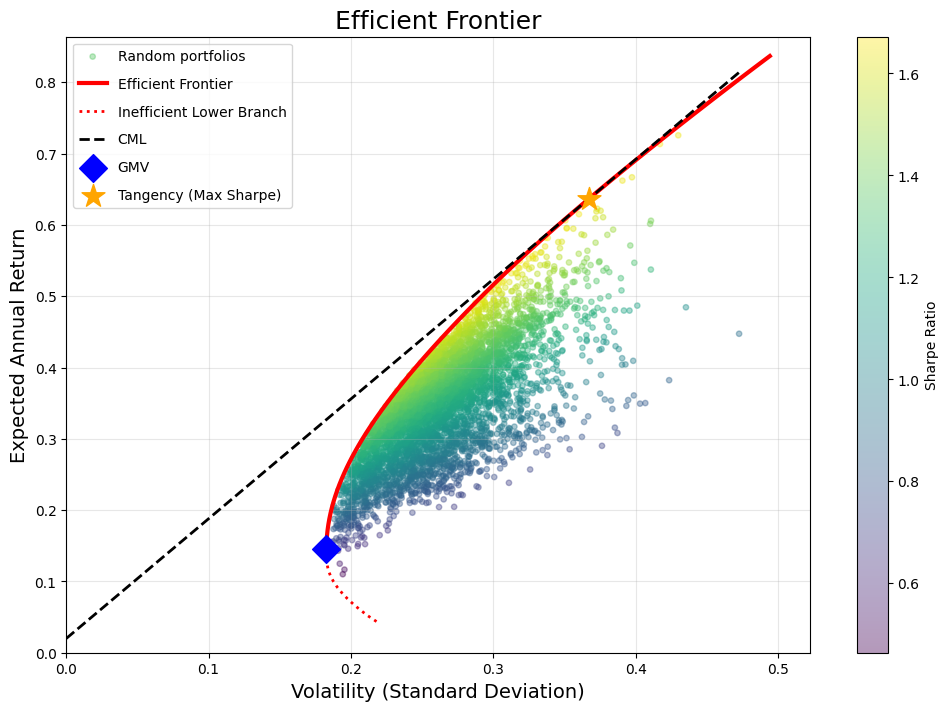

In [117]:
#  Calculate the Exact Efficient Frontier Curve ---
num_portfolios = 5000
all_weights = np.zeros((num_portfolios, num_assets))
ret_arr = np.zeros(num_portfolios)
vol_arr = np.zeros(num_portfolios)
sharpe_arr = np.zeros(num_portfolios)

for ind in range(num_portfolios):
        weights = np.array(np.random.random(num_assets))
        weights = weights / np.sum(weights)
        all_weights[ind, :] = weights
        ret_arr[ind] = np.sum(mean_returns * weights)
        vol_arr[ind] = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
        sharpe_arr[ind] = (ret_arr[ind] - risk_free_rate) / vol_arr[ind]

target_returns = np.linspace(mean_returns.min(), mean_returns.max(), 100)
efficient_vols = []

for target in target_returns:
    constraints_eff = (
        {'type': 'eq', 'fun': lambda x: np.sum(x) - 1},
        {'type': 'eq', 'fun': lambda x: np.sum(mean_returns * x) - target}
    )

    try:
        res = minimize(volatility_func, init_guess, args=args, method='SLSQP',
                       bounds=bounds, constraints=constraints_eff)
        if res.success:
            efficient_vols.append(res.fun)
        else:
            efficient_vols.append(np.nan)
    except:
        efficient_vols.append(np.nan)

efficient_vols = np.array(efficient_vols)

# Split the curve
mask_upper = target_returns >= mv_ret
eff_ret_upper = target_returns[mask_upper]
eff_vol_upper = efficient_vols[mask_upper]

mask_lower = target_returns <= mv_ret
eff_ret_lower = target_returns[mask_lower]
eff_vol_lower = efficient_vols[mask_lower]

# --- CML Calculation ---
cml_x = np.linspace(0, max(vol_arr), 100)
cml_y = risk_free_rate + (ms_sharpe * cml_x)

# 2. Plotting
plt.figure(figsize=(12, 8))

# Scatter Cloud
sc = plt.scatter(vol_arr, ret_arr, c=sharpe_arr, cmap='viridis', alpha=0.4, s=15, label='Random portfolios')
plt.colorbar(sc, label='Sharpe Ratio')

# Efficient Frontier Lines
plt.plot(eff_vol_upper, eff_ret_upper, 'r-', linewidth=3, label='Efficient Frontier')
plt.plot(eff_vol_lower, eff_ret_lower, 'r:', linewidth=2, label='Inefficient Lower Branch')

# CML
plt.plot(cml_x, cml_y, color='black', linestyle='--', linewidth=2, label='CML')

# Markers
plt.scatter(mv_vol, mv_ret, c='blue', marker='D', s=200, label='GMV', zorder=5)
plt.scatter(ms_vol, ms_ret, c='orange', marker='*', s=300, label='Tangency (Max Sharpe)', zorder=5)

# Formatting
plt.title('Efficient Frontier', fontsize=18)
plt.xlabel('Volatility (Standard Deviation)', fontsize=14)
plt.ylabel('Expected Annual Return', fontsize=14)
plt.legend(labelspacing=1.0, loc='best')
plt.grid(True, alpha=0.3)
plt.xlim(0, max(vol_arr) + 0.05)
plt.ylim(0, max(cml_y) + 0.05)

plt.show()

/tmp/ipython-input-3245830975.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  (asset_volatility[i], mean_returns[i]),


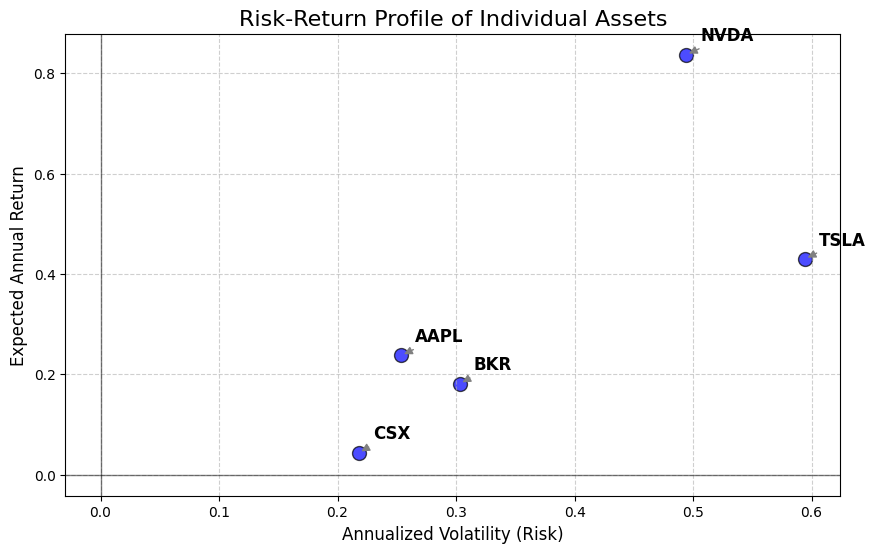

In [118]:
# --- Plotting Risk-Return Profile of Individual Assets ---
plt.figure(figsize=(10, 6))

# 1. Create the Scatter Plot
plt.scatter(asset_volatility, mean_returns, s=100, c='blue', alpha=0.7, edgecolors='black')

# 2. Add Labels to points
for i, ticker in enumerate(tickers):
    plt.annotate(ticker,
                 (asset_volatility[i], mean_returns[i]),
                 xytext=(10, 10),
                 textcoords='offset points',
                 fontsize=12,
                 fontweight='bold',
                 arrowprops=dict(arrowstyle="-|>", color='gray'))

# 3. Formatting
plt.title('Risk-Return Profile of Individual Assets', fontsize=16)
plt.xlabel('Annualized Volatility (Risk)', fontsize=12)
plt.ylabel('Expected Annual Return', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

# Optional: Add axis lines at 0 for clarity
plt.axhline(0, color='black', linewidth=1, alpha=0.5)
plt.axvline(0, color='black', linewidth=1, alpha=0.5)

plt.show()

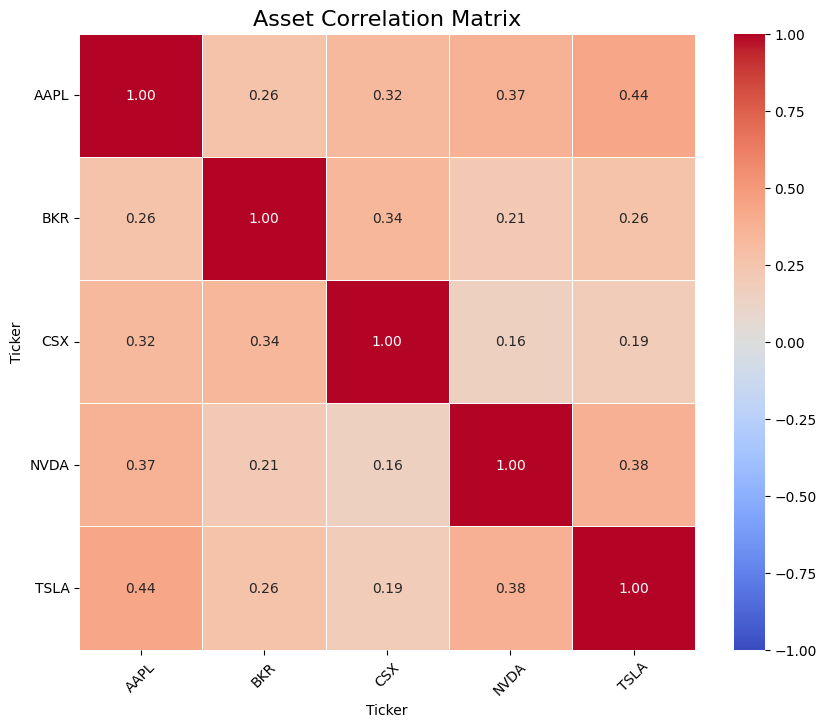

In [119]:
# --- Plotting Correlation Heatmap ---
plt.figure(figsize=(10, 8))

# 1. Calculate Correlation Matrix
correlation_matrix = log_returns.corr()

# 2. Create Heatmap
sns.heatmap(correlation_matrix,
            annot=True,          # Show the correlation numbers
            cmap='coolwarm',     # Red for positive, Blue for negative
            center=0,            # Center the color scale at 0
            vmin=-1, vmax=1,     # Ensure scale goes from -1 to 1
            linewidths=0.5,      # Spacing between squares
            fmt=".2f",           # 2 decimal places
            square=True)         # Force square cells

# 3. Formatting
plt.title('Asset Correlation Matrix', fontsize=16)
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.show()

In [120]:
# --- BLOCK 1: Market Data Setup ---

print("Downloading Market Data (S&P 500)...")
# 1. Fetch S&P 500 Data
market_ticker = ['^GSPC']
market_data = yf.download(market_ticker, start=start_date, end=end_date, auto_adjust=True)

# 2. Process Market Data
if 'Close' in market_data.columns and isinstance(market_data.columns, pd.MultiIndex):
    market_close = market_data['Close']
else:
    market_close = market_data

# Calculate Market Log Returns
market_log_returns = np.log(market_close / market_close.shift(1)).dropna()

# 3. Align Data (Crucial Step)
# This combines your 'log_returns' with 'market_log_returns' to ensure dates match
aligned_data = pd.concat([log_returns, market_log_returns], axis=1).dropna()
aligned_data.columns = tickers + ['Market']

# Separate them back out for calculations
aligned_market = aligned_data['Market']
market_return_annual = aligned_market.mean() * TRADING_DAYS
market_var_annual = aligned_market.var() * TRADING_DAYS

print("Market data ready.")

[*********************100%***********************]  1 of 1 completed

Market data ready.


In [121]:
# --- BLOCK 2: Individual Stock CAPM ---

capm_results = []

print("Calculating Individual Metrics...")

for ticker in tickers:
    # 1. Calculate Beta
    # Formula: Cov(Stock, Market) / Var(Market)
    stock_returns = aligned_data[ticker]
    covariance = np.cov(stock_returns, aligned_market)[0][1] * TRADING_DAYS
    beta = covariance / market_var_annual

    # 2. CAPM Expected Return
    # Formula: Rf + Beta * (Rm - Rf)
    expected_return_capm = risk_free_rate + beta * (market_return_annual - risk_free_rate)

    # 3. Actual Return
    actual_return = stock_returns.mean() * TRADING_DAYS

    # 4. Jensen's Alpha
    # Formula: Actual Return - Expected Return
    alpha = actual_return - expected_return_capm

    capm_results.append([ticker, beta, expected_return_capm, actual_return, alpha])

# Create DataFrame
df_capm = pd.DataFrame(capm_results, columns=['Ticker', 'Beta', 'CAPM Exp Return', 'Actual Return', 'Jensen Alpha'])
df_capm.set_index('Ticker', inplace=True)

print("\n--- Individual Stock CAPM Metrics ---")
print(df_capm)

Calculating Individual Metrics...

--- Individual Stock CAPM Metrics ---
            Beta  CAPM Exp Return  Actual Return  Jensen Alpha
Ticker                                                        
AAPL    1.157403         0.220399       0.237650      0.017251
BKR     1.005596         0.194114       0.181319     -0.012796
CSX     0.733210         0.146952       0.043741     -0.103211
NVDA    2.132436         0.389221       0.836957      0.447736
TSLA    2.307781         0.419582       0.430006      0.010424


In [122]:
# --- BLOCK 3: Portfolio CAPM ---

# 1. Define Helper Functions for Optimization
def get_metrics(weights, means, cov, rf):
    weights = np.array(weights)
    ret = np.sum(means * weights)
    vol = np.sqrt(np.dot(weights.T, np.dot(cov, weights)))
    sharpe = (ret - rf) / vol
    return ret, vol, sharpe

def neg_sharpe(weights, means, cov, rf):
    return -get_metrics(weights, means, cov, rf)[2]

def vol_func(weights, means, cov, rf):
    return get_metrics(weights, means, cov, rf)[1]

# 2. Run Optimization to get Weights
num_assets = len(tickers)
args = (mean_returns, cov_matrix, risk_free_rate)
constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
bounds = tuple((0, 1) for _ in range(num_assets))
init_guess = num_assets * [1. / num_assets,]

# Max Sharpe Weights
ms_res = minimize(neg_sharpe, init_guess, args=args, method='SLSQP', bounds=bounds, constraints=constraints)
ms_weights = ms_res.x

# Min Volatility Weights
mv_res = minimize(vol_func, init_guess, args=args, method='SLSQP', bounds=bounds, constraints=constraints)
mv_weights = mv_res.x

# Equal Weights
ew_weights = np.array([1/num_assets] * num_assets)

# 3. Calculate Portfolio CAPM
portfolio_list = [
    ("Max Sharpe", ms_weights),
    ("Min Volatility", mv_weights),
    ("Equal Weight", ew_weights)
]

port_results = []

for name, weights in portfolio_list:
    # Portfolio Beta = Weighted Sum of Individual Betas
    port_beta = np.sum(weights * df_capm['Beta'])

    # Portfolio CAPM Expected Return
    port_exp_capm = risk_free_rate + port_beta * (market_return_annual - risk_free_rate)

    # Portfolio Actual Return
    port_actual = np.sum(weights * df_capm['Actual Return'])

    # Portfolio Alpha
    port_alpha = port_actual - port_exp_capm

    port_results.append([name, port_beta, port_exp_capm, port_actual, port_alpha])

df_port = pd.DataFrame(port_results, columns=['Portfolio', 'Beta', 'CAPM Exp Return', 'Actual Return', 'Jensen Alpha'])
df_port.set_index('Portfolio', inplace=True)

print("\n--- Portfolio CAPM Metrics ---")
print(df_port)


--- Portfolio CAPM Metrics ---
                    Beta  CAPM Exp Return  Actual Return  Jensen Alpha
Portfolio                                                             
Max Sharpe      1.800890         0.331816       0.636925      0.305109
Min Volatility  0.942473         0.183185       0.144988     -0.038197
Equal Weight    1.467285         0.274054       0.345934      0.071881


In [123]:
# --- BLOCK 1: Risk Decomposition ---

print("\n--- Risk Decomposition (Systematic vs. Idiosyncratic) ---")

# 1. Define Helper for Decomposition
def decompose_risk(name, beta, total_volatility, market_var_annual):
    # Total Variance = Volatility^2
    total_var = total_volatility ** 2

    # Systematic Variance = Beta^2 * Market Variance
    sys_var = (beta ** 2) * market_var_annual

    # Idiosyncratic Variance = Total Variance - Systematic Variance
    idio_var = total_var - sys_var

    # Calculate R-Squared (Percentage of risk explained by market)
    r_squared = sys_var / total_var

    return [name, total_var, sys_var, idio_var, r_squared]

# 2. Decompose Individual Stocks
risk_data = []
for ticker in tickers:
    beta = df_capm.loc[ticker, 'Beta']

    # Get total volatility (from your earlier calculations)
    # We need to ensure we use the annualized volatility calculated earlier
    total_vol = asset_volatility[ticker]

    risk_data.append(decompose_risk(ticker, beta, total_vol, market_var_annual))

# 3. Decompose Portfolios
for name, weights in [("Max Sharpe", ms_weights), ("Min Volatility", mv_weights), ("Equal Weight", ew_weights)]:
    # Get Portfolio Beta
    port_beta = df_port.loc[name, 'Beta']

    # Calculate Portfolio Volatility manually for the formula
    port_vol = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))

    risk_data.append(decompose_risk(name, port_beta, port_vol, market_var_annual))

# 4. Create DataFrame & Format
df_risk = pd.DataFrame(risk_data, columns=['Asset', 'Total Var', 'Systematic Var', 'Idiosyncratic Var', 'R-Squared'])
df_risk.set_index('Asset', inplace=True)

# Format for Display (Percentages)
df_risk_display = df_risk.copy()
df_risk_display['R-Squared'] = df_risk_display['R-Squared'].map('{:.2%}'.format) # % of risk from market
df_risk_display['Systematic Var'] = df_risk_display['Systematic Var'].map('{:.4f}'.format)
df_risk_display['Idiosyncratic Var'] = df_risk_display['Idiosyncratic Var'].map('{:.4f}'.format)

print(df_risk_display)
print("\nNote: R-Squared represents the % of risk that is Systematic (Market-related).")


--- Risk Decomposition (Systematic vs. Idiosyncratic) ---
                Total Var Systematic Var Idiosyncratic Var R-Squared
Asset                                                               
AAPL             0.064487         0.0300            0.0345    46.51%
BKR              0.091980         0.0226            0.0693    24.61%
CSX              0.047505         0.0120            0.0355    25.34%
NVDA             0.244318         0.1018            0.1425    41.67%
TSLA             0.353390         0.1192            0.2341    33.74%
Max Sharpe       0.134883         0.0726            0.0623    53.83%
Min Volatility   0.033387         0.0199            0.0135    59.57%
Equal Weight     0.064318         0.0482            0.0161    74.94%

Note: R-Squared represents the % of risk that is Systematic (Market-related).


[*********************100%***********************]  1 of 1 completed


--- Calculating Betas (vs SPY) ---
Betas calculated: {'AAPL': np.float64(1.1420527191535208), 'BKR': np.float64(0.9980183379253174), 'CSX': np.float64(0.7230958581851752), 'NVDA': np.float64(2.073596973538131), 'TSLA': np.float64(2.251155477871862)}

--- Generating Critical Assessment Plot ---


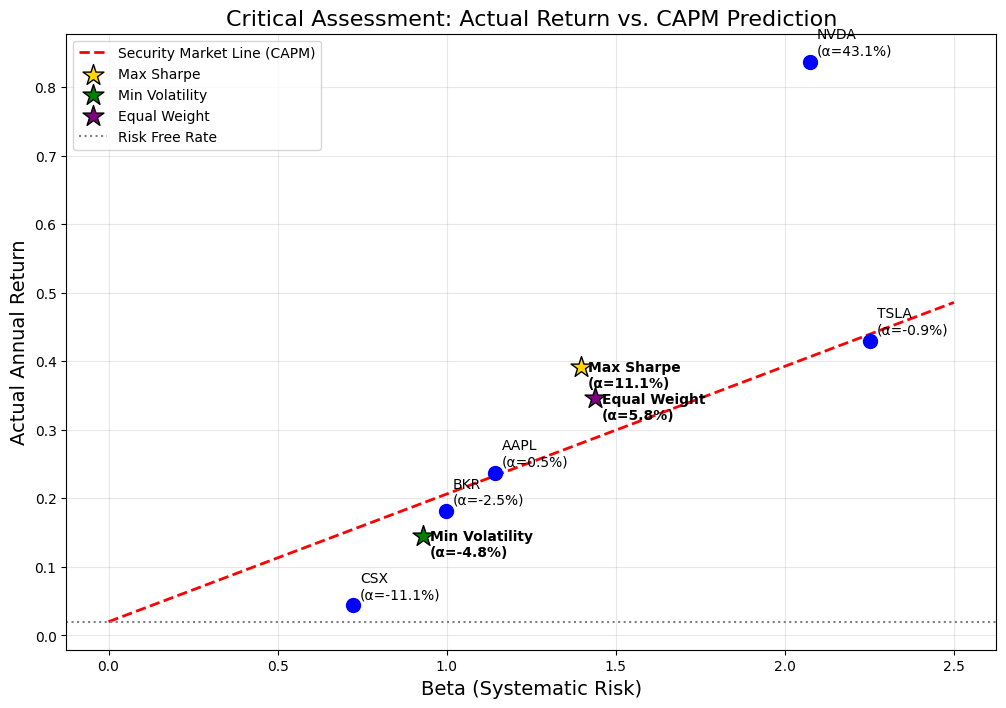

Plot Generated Successfully.


In [124]:
# ==========================================
# PASTE THIS DIRECTLY AFTER YOUR SETUP CODE
# ==========================================

# ---------------------------------------------------------
# STEP 1: Calculate Betas (Systematic Risk)
# ---------------------------------------------------------
print("\n--- Calculating Betas (vs SPY) ---")

# 1. Download Market Data (SPY) to compare against
# We use the same date range and auto_adjust=True to match your stock data
market_data = yf.download('SPY', start=start_date, end=end_date, auto_adjust=True)

# Handle potential multi-level column index (common in new yfinance)
if isinstance(market_data.columns, pd.MultiIndex):
    market_prices = market_data['Close']['SPY']
else:
    market_prices = market_data['Close']

# 2. Calculate Market Log Returns (Consistent with your setup)
market_log_returns = np.log(market_prices / market_prices.shift(1)).dropna()
market_var = market_log_returns.var()

# 3. Calculate Beta for each stock
betas = {}
for ticker in tickers:
    # Align Stock and Market data by Date
    combined = pd.concat([log_returns[ticker], market_log_returns], axis=1).dropna()
    combined.columns = ['Stock', 'Market']

    # Beta = Covariance(Stock, Market) / Variance(Market)
    cov = combined['Stock'].cov(combined['Market'])
    betas[ticker] = cov / market_var

print("Betas calculated:", betas)

# ---------------------------------------------------------
# STEP 2: Define Portfolios
# ---------------------------------------------------------

# Helper function to get portfolio return (for plotting)
def get_port_return(weights):
    return np.sum(np.array(weights) * mean_returns)

# 1. Robust Max Sharpe (Mapped to your ticker order)
# Your ticker list is: ['AAPL', 'BKR', 'CSX', 'NVDA', 'TSLA']
# Weights from your image: AAPL(28.75%), BKR(28.75%), CSX(8.10%), NVDA(29.40%), TSLA(5.00%)
w_max_sharpe = np.array([0.2875, 0.2875, 0.0810, 0.2940, 0.0500])

# 2. Equal Weight Benchmark
num_assets = len(tickers)
w_equal = np.array([1/num_assets] * num_assets)

# 3. Min Volatility (Calculated via Optimization)
def min_vol_func(w):
    return np.sqrt(np.dot(w.T, np.dot(cov_matrix, w)))

constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
bounds = tuple((0, 1) for _ in range(num_assets))
res = sco.minimize(min_vol_func, w_equal, method='SLSQP', bounds=bounds, constraints=constraints)
w_min_vol = res.x

# Group them for plotting
portfolios = [
    ('Max Sharpe', w_max_sharpe),
    ('Min Volatility', w_min_vol),
    ('Equal Weight', w_equal)
]

# ---------------------------------------------------------
# STEP 3: Generate the Plot
# ---------------------------------------------------------
print("\n--- Generating Critical Assessment Plot ---")
plt.figure(figsize=(12, 8))

# A. Plot the Security Market Line (SML)
# We calculate the actual annualized market return from the SPY data we just downloaded
actual_market_return = market_log_returns.mean() * 252
max_beta_plot = max(max(betas.values()), 2.5) # Set axis limit

x_sml = np.linspace(0, max_beta_plot, 100)
y_sml = risk_free_rate + x_sml * (actual_market_return - risk_free_rate)

plt.plot(x_sml, y_sml, 'r--', linewidth=2, label='Security Market Line (CAPM)')

# B. Plot Individual Stocks
for ticker in tickers:
    actual_ret = mean_returns[ticker]
    beta = betas[ticker]

    # Calculate Alpha (Excess return vs CAPM prediction)
    expected_ret = risk_free_rate + beta * (actual_market_return - risk_free_rate)
    alpha = actual_ret - expected_ret

    plt.scatter(beta, actual_ret, c='blue', s=100, zorder=5)
    plt.annotate(f"{ticker}\n(α={alpha:.1%})", (beta, actual_ret), xytext=(5, 5), textcoords='offset points')

# C. Plot Portfolios
colors = {'Max Sharpe': 'gold', 'Min Volatility': 'green', 'Equal Weight': 'purple'}

for name, weights in portfolios:
    # Portfolio Beta is the weighted sum of individual betas
    port_beta = np.sum(weights * np.array([betas[t] for t in tickers]))
    port_ret = get_port_return(weights)

    expected_ret = risk_free_rate + port_beta * (actual_market_return - risk_free_rate)
    alpha = port_ret - expected_ret

    plt.scatter(port_beta, port_ret, c=colors[name], s=250, marker='*', edgecolors='black', zorder=10, label=name)
    plt.annotate(f"{name}\n(α={alpha:.1%})", (port_beta, port_ret), xytext=(5, -15), textcoords='offset points', fontweight='bold')

# Formatting
plt.title('Critical Assessment: Actual Return vs. CAPM Prediction', fontsize=16)
plt.xlabel('Beta (Systematic Risk)', fontsize=14)
plt.ylabel('Actual Annual Return', fontsize=14)
plt.axhline(risk_free_rate, color='gray', linestyle=':', label='Risk Free Rate')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)

plt.show()

print("Plot Generated Successfully.")

In [125]:
# --- BLOCK: Constrained (Robust) Max Sharpe Optimization ---

print("--- Running Robust Max Sharpe Optimization ---")

# 1. Define Constraints (Min 5%, Max 30%)
min_weight = 0.05
max_weight = 0.30
bounds_constrained = tuple((min_weight, max_weight) for _ in range(num_assets))

# Standard equality constraint (Weights sum to 1)
constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})

# 2. Optimize for Maximum Sharpe Ratio
# We use 'neg_sharpe_ratio' because we want to MAXIMIZE Sharpe (so we minimize negative Sharpe)
robust_sharpe_res = minimize(neg_sharpe_ratio, init_guess, args=args,
                             method='SLSQP', bounds=bounds_constrained, constraints=constraints)

robust_sharpe_weights = robust_sharpe_res.x
rob_s_ret, rob_s_vol, rob_s_sharpe = get_portfolio_metrics(robust_sharpe_weights, mean_returns, cov_matrix, risk_free_rate)

# 3. Display Results
print(f"\nRobust Max Sharpe Portfolio (Min {min_weight:.0%}, Max {max_weight:.0%}):")
print(f"Return: {rob_s_ret:.2%}")
print(f"Volatility: {rob_s_vol:.2%}")
print(f"Sharpe Ratio: {rob_s_sharpe:.2f}")
print("\nWeights:")
for ticker, weight in zip(tickers, robust_sharpe_weights):
    print(f"  {ticker}: {weight:.2%}")

# Check if constraints were met
if robust_sharpe_res.success:
    print("\nOptimization Status: Success (Constraints Satisfied)")
else:
    print("\nOptimization Status: Failed to find solution within constraints")

--- Running Robust Max Sharpe Optimization ---

Robust Max Sharpe Portfolio (Min 5%, Max 30%):
Return: 39.56%
Volatility: 24.81%
Sharpe Ratio: 1.51

Weights:
  AAPL: 30.00%
  BKR: 26.48%
  CSX: 8.52%
  NVDA: 30.00%
  TSLA: 5.00%

Optimization Status: Success (Constraints Satisfied)



--- 2. Running Rolling-Window Analysis ---


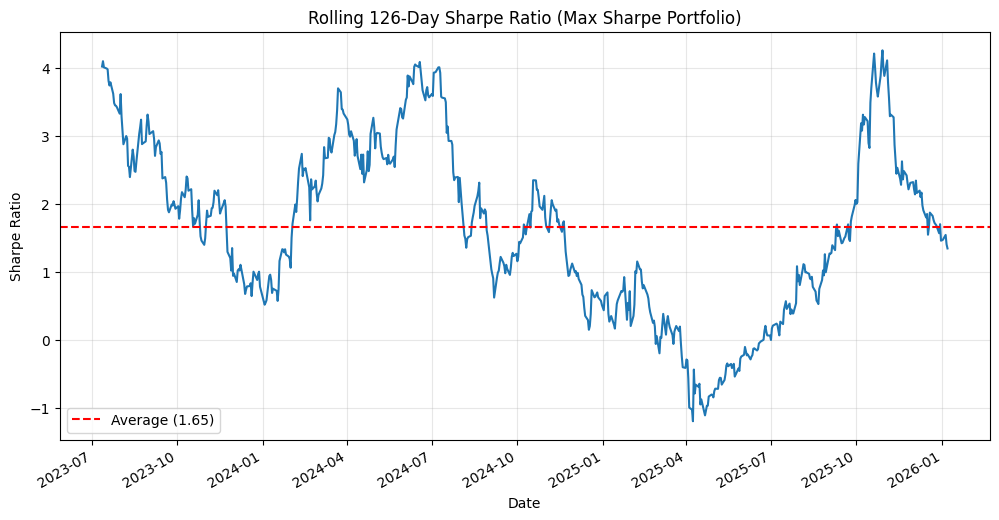

Interpretation: A stable line indicates robust performance. Large dips indicate periods where the strategy failed.


In [126]:
# --- BLOCK 2: Rolling-Window Analysis ---

print("\n--- 2. Running Rolling-Window Analysis ---")

# 1. Define Window Size (e.g., 126 trading days = ~6 months)
window = 126

# 2. Calculate Daily Portfolio Returns
# We will use the 'ms_weights' (Max Sharpe Weights) calculated earlier
# If you haven't run that block, replace 'ms_weights' with 'ew_weights' (Equal Weight)
portfolio_daily_returns = (log_returns * ms_weights).sum(axis=1)

# 3. Calculate Rolling Metrics
rolling_mean = portfolio_daily_returns.rolling(window=window).mean() * TRADING_DAYS
rolling_vol = portfolio_daily_returns.rolling(window=window).std() * np.sqrt(TRADING_DAYS)
rolling_sharpe = (rolling_mean - risk_free_rate) / rolling_vol

# 4. Plotting
plt.figure(figsize=(12, 6))
rolling_sharpe.plot(title=f'Rolling {window}-Day Sharpe Ratio (Max Sharpe Portfolio)')

# Add a horizontal line for the average
avg_sharpe = rolling_sharpe.mean()
plt.axhline(avg_sharpe, color='red', linestyle='--', label=f'Average ({avg_sharpe:.2f})')

plt.ylabel('Sharpe Ratio')
plt.xlabel('Date')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("Interpretation: A stable line indicates robust performance. Large dips indicate periods where the strategy failed.")

In [127]:
# --- BLOCK 3: Risk Parity (Equal Risk Contribution) ---

print("\n--- 3. Constructing Risk Parity Portfolio ---")

# 1. Define Risk Parity Objective Function
def risk_budget_objective(weights, cov_matrix):
    weights = np.array(weights).reshape(-1, 1) # Ensure correct shape

    # Portfolio Volatility
    port_vol = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights))).item()

    # Marginal Risk Contribution of each asset
    mrc = np.dot(cov_matrix, weights) / port_vol

    # Risk Contribution = Weight * Marginal Risk
    rc = weights * mrc

    # We want all Risk Contributions to be equal (1/N)
    target_rc = port_vol / len(weights)

    # Minimize the sum of squared errors between Actual RC and Target RC
    return np.sum((rc - target_rc)**2)

# 2. Optimization Setup
init_guess_rp = [1/num_assets] * num_assets
bounds_rp = tuple((0, 1) for _ in range(num_assets))
constraints_rp = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})

# 3. Run Optimization
rp_res = minimize(risk_budget_objective, init_guess_rp, args=(cov_matrix,),
                  method='SLSQP', bounds=bounds_rp, constraints=constraints_rp)

erc_weights = rp_res.x
erc_ret, erc_vol, erc_sharpe = get_portfolio_metrics(erc_weights, mean_returns, cov_matrix, risk_free_rate)

# 4. Compare Risk Parity vs Max Sharpe
print("\n--- Comparison: Risk Parity vs Max Sharpe ---")
print(f"{'Metric':<15} {'Risk Parity':<15} {'Max Sharpe':<15}")
print(f"{'Return':<15} {erc_ret:<15.2%} {ms_ret:<15.2%}")
print(f"{'Volatility':<15} {erc_vol:<15.2%} {ms_vol:<15.2%}")
print(f"{'Sharpe':<15} {erc_sharpe:<15.2f} {ms_sharpe:<15.2f}")

print("\nRisk Parity Weights:")
for ticker, weight in zip(tickers, erc_weights):
    print(f"  {ticker}: {weight:.2%}")


--- 3. Constructing Risk Parity Portfolio ---

--- Comparison: Risk Parity vs Max Sharpe ---
Metric          Risk Parity     Max Sharpe     
Return          26.54%          63.69%         
Volatility      21.08%          36.73%         
Sharpe          1.16            1.68           

Risk Parity Weights:
  AAPL: 23.81%
  BKR: 21.55%
  CSX: 30.91%
  NVDA: 13.31%
  TSLA: 10.42%


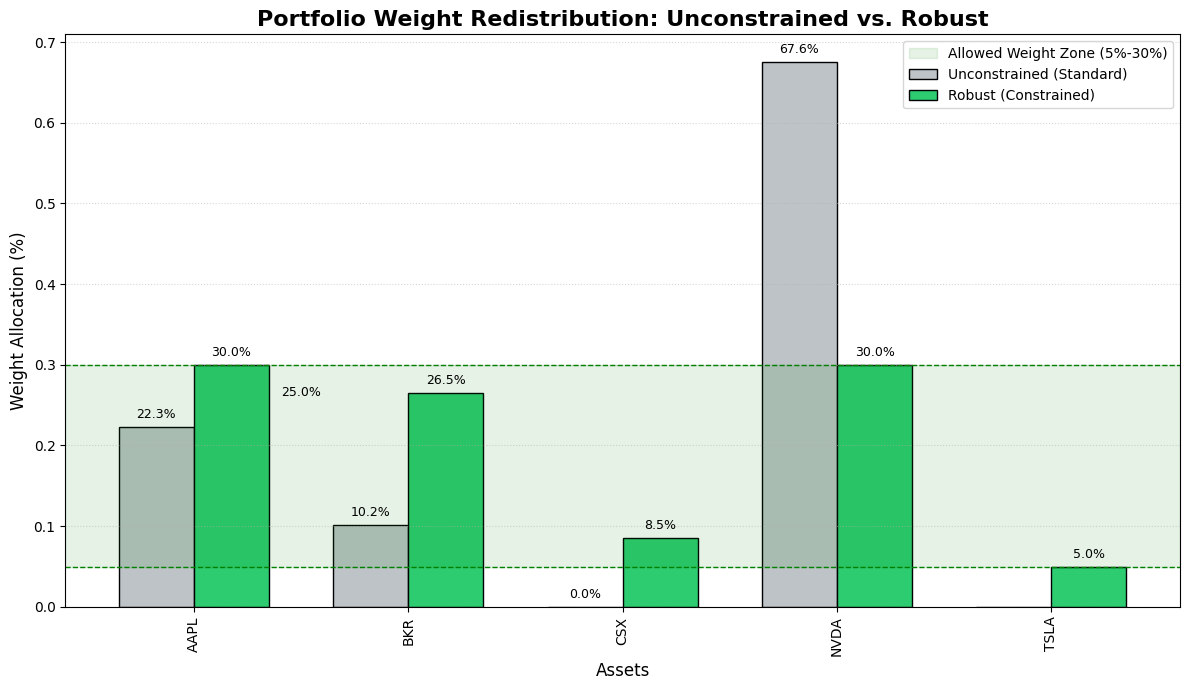

In [128]:
# --- BLOCK 1: Visualization - Standard vs. Robust Weights ---
import matplotlib.patches as mpatches

# 1. Prepare Data for Plotting
# We assume 'ms_weights' (Standard) and 'robust_sharpe_weights' (Robust) exist from previous steps.
# If 'robust_sharpe_weights' isn't defined yet, run the robust optimization block first.

df_compare = pd.DataFrame({
    'Unconstrained (Standard)': ms_weights,
    'Robust (Constrained)': robust_sharpe_weights
}, index=tickers)

# 2. Setup Plot
fig, ax = plt.subplots(figsize=(12, 7))

# 3. Create Grouped Bar Chart
df_compare.plot(kind='bar', ax=ax, width=0.7, color=['#bdc3c7', '#2ecc71'], edgecolor='black')

# 4. Add "Constraint Zone" Shading
# This highlights the allowed region (5% to 30%)
ax.axhspan(min_weight, max_weight, color='green', alpha=0.1, label='Allowed Weight Zone (5%-30%)')
ax.axhline(min_weight, color='green', linestyle='--', linewidth=1)
ax.axhline(max_weight, color='green', linestyle='--', linewidth=1)

# 5. Formatting
ax.set_title('Portfolio Weight Redistribution: Unconstrained vs. Robust', fontsize=16, fontweight='bold')
ax.set_ylabel('Weight Allocation (%)', fontsize=12)
ax.set_xlabel('Assets', fontsize=12)
ax.legend(loc='upper right', frameon=True)
ax.grid(axis='y', linestyle=':', alpha=0.5)

# Add value labels on top of bars
for p in ax.patches:
    if p.get_height() > 0: # Only label non-zero bars
        ax.annotate(f"{p.get_height():.1%}",
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center',
                    xytext=(0, 9), textcoords='offset points', fontsize=9)

plt.tight_layout()
plt.show()

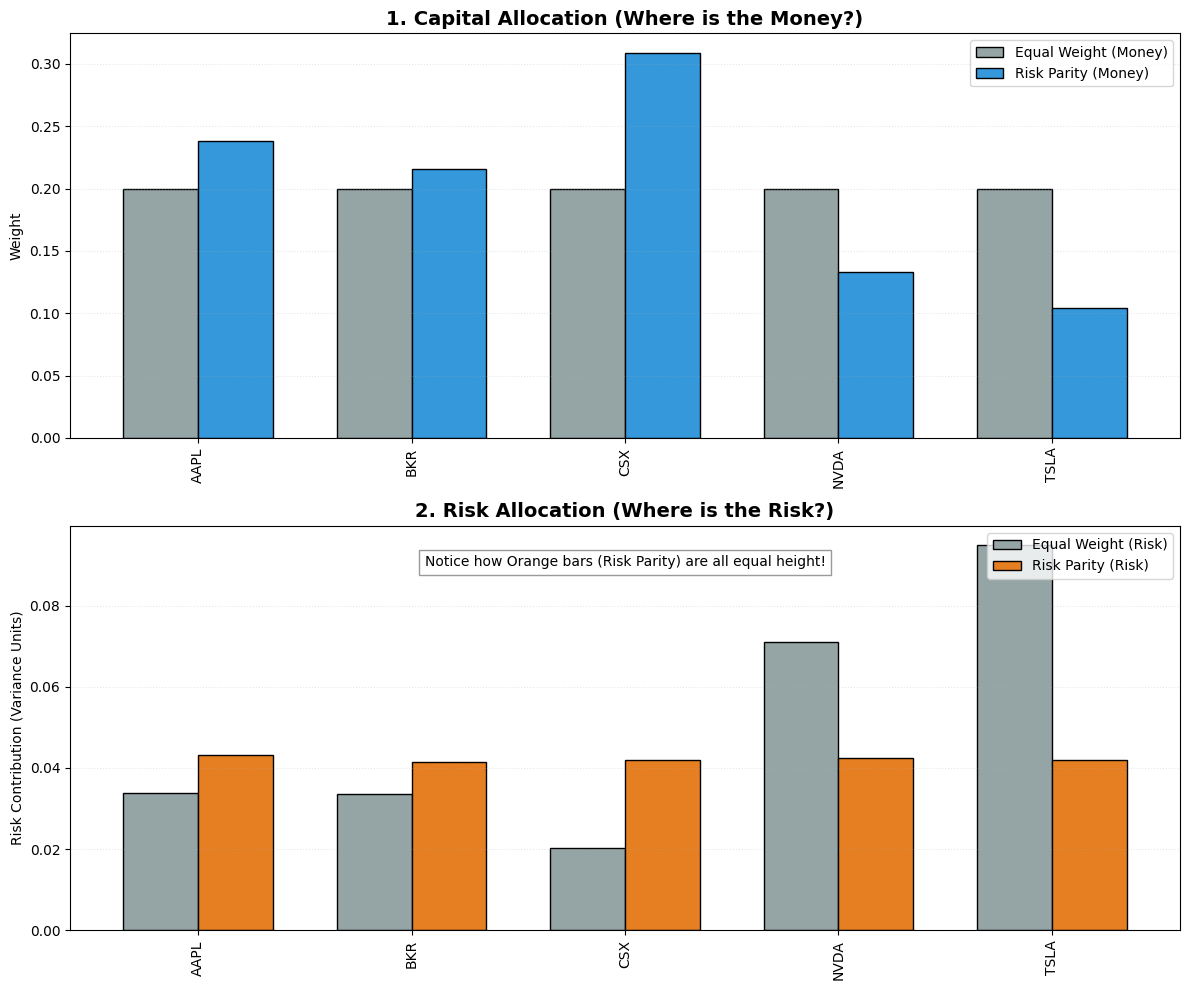

In [129]:
# --- BLOCK 2: Visualization - Risk Parity Analysis ---

# 1. Helper Function to Calculate Risk Contribution
def calculate_risk_contribution(weights, cov_matrix):
    weights = np.array(weights)
    # Portfolio Volatility
    port_vol = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    # Marginal Risk Contribution
    mrc = np.dot(cov_matrix, weights) / port_vol
    # Risk Contribution = Weight * MRC
    rc = weights * mrc
    return rc

# 2. Calculate Risk Contributions for both portfolios
# Equal Weight Portfolio Risk Contributions
ew_risk_contrib = calculate_risk_contribution(ew_weights, cov_matrix)

# Risk Parity Portfolio Risk Contributions (erc_weights comes from previous Risk Parity block)
rp_risk_contrib = calculate_risk_contribution(erc_weights, cov_matrix)

# 3. Prepare DataFrames
df_weights_rp = pd.DataFrame({
    'Equal Weight (Money)': ew_weights,
    'Risk Parity (Money)': erc_weights
}, index=tickers)

df_risk_rp = pd.DataFrame({
    'Equal Weight (Risk)': ew_risk_contrib,
    'Risk Parity (Risk)': rp_risk_contrib
}, index=tickers)

# 4. Create Subplots (2 Rows)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# --- Top Plot: Capital Allocation (Weights) ---
df_weights_rp.plot(kind='bar', ax=ax1, color=['#95a5a6', '#3498db'], width=0.7, edgecolor='black')
ax1.set_title('1. Capital Allocation (Where is the Money?)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Weight')
ax1.legend(loc='upper right')
ax1.grid(axis='y', linestyle=':', alpha=0.3)

# --- Bottom Plot: Risk Allocation (Contribution to Volatility) ---
df_risk_rp.plot(kind='bar', ax=ax2, color=['#95a5a6', '#e67e22'], width=0.7, edgecolor='black')
ax2.set_title('2. Risk Allocation (Where is the Risk?)', fontsize=14, fontweight='bold')
ax2.set_ylabel('Risk Contribution (Variance Units)')
ax2.legend(loc='upper right')
ax2.grid(axis='y', linestyle=':', alpha=0.3)

# Annotation for clarity
ax2.text(0.5, 0.9, "Notice how Orange bars (Risk Parity) are all equal height!",
         transform=ax2.transAxes, ha='center', fontsize=10,
         bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))

plt.tight_layout()
plt.show()